## __Brief Intro to PCA__
PCA standing for Principal Component Analysis is mostly used for reducing the dimension of datasets, and for such reason it's commonly known as dimensional reduction algorithm.

Because of PCA's dimensional reduction ability, it can be used:

To visualize high dimensional datasets, particuraly because visualizing such high level datasets is impractical.

Before a typical machine learning model training to merely increase the training speed, given that the training data is reduced or no longer contain redundant features. It is not guaranteed to speed up but in some cases, it can.

Select most useful features while getting the rid of useless information. But not always, sometime useful information will be lost too especially if the original data was already good and didn't contain noises.

While the above can sound compelling (and they are), the features returned by PCA can be hard to interpret and it adds complexity that could turn out to be disadvantages than advantages.

PCA is well implemented in [Scikit-Learn](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda) and it has different versions such as Randomized PCA, Kernel PCA, and Incremental PCA(mostly for online learning).

In many ML resources, you will find PCA in the category of unsupervised learning algorithms. Here is a simple reason: PCA reduces the dimension of datasets without instructions (labels in other word) of how that is going to be done other than specifying the number of principal components, just like specifying the number of clusters in KMeans clustering.

While the maths and deep concepts behind PCA are beyond the scope this notebook, we will try to have a practical understanding of the above PCA's usecases.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

### __PCA for Dimension Reduction__
In this section, we are going to use PCA for reducing the dimension of a structured dataset. In the next example, we will use it for visualizing high dimensional datasets.

We will use wine dataset. Check the data description down.



In [3]:
from sklearn.datasets import load_wine

wine=load_wine()

X = wine.data 

y = wine.target

feat_names = wine.feature_names

target_names = wine.target_names

In [4]:
feat_names, target_names

(['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'],
 array(['class_0', 'class_1', 'class_2'], dtype='<U7'))

In [5]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [6]:
X.shape , y.shape

((178, 13), (178,))

Before applying __PCA__ to the dataset, let's first scale the input data with `StandardScaler`.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### Applying PCA
Scikit-Learn is remarkably well designed. Just like how simple it is to use almost all algorithms implemented in Scikit-Learn, using PCA is no different. It's just `fit` and `transform`.

In the process to reduce the dataset dimensionality, we have to specify the number of principal components. Think principal components as coordinates that we want to project the data in.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

__How n_components works__:
* *Integer Value* (e.g., `n_components=2`): When n_components is set to an integer, PCA will reduce the data to exactly that many principal components. This is useful when you have a specific target dimensionality for visualization (e.g., 2D or 3D) or to fit a subsequent machine learning model.\
* *Float Value* between 0 and 1 (e.g., `n_components=0.95`): When n_components is set to a float value between 0 and 1, it represents the desired proportion of explained variance to retain. PCA will automatically select the minimum number of principal components required to explain at least that percentage of the total variance in the original data. This is often used to reduce dimensionality while preserving a significant amount of information.
* *Default (None)*: If n_components is `not specified`, PCA will retain all principal components, effectively transforming the data without reducing its dimensionality.

__Important notes__: Using the scaled data (X_scaled) in pca.fit_transform() reduces the explained variance ratio to about [0.36198848, 0.1920749]. If you have found any mismatch in the upcoming section of we discussed about `Explained Variance Ratio`, this was the reason.

I will use the unscaled version of the data for such reason.

In [9]:
X_reduced = pca.fit_transform(X)

In [10]:
print('The shape of orginal dataset(without PCA):{}\nThe shape of reduced dataset due to PCA:{}'.format(X.shape, X_reduced.shape))

The shape of orginal dataset(without PCA):(178, 13)
The shape of reduced dataset due to PCA:(178, 2)


That was so fast. For now, we have reduced the dataset from 13 dimensions to 2 dimensions.

### __Visualizing the Principal Components__

Let's try to visualize the 2 principal components. We will also add the labels of the wine datasets or target_names.

/tmp/ipykernel_622/1799000104.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_reduced[y==num_class,0], X_reduced[y==num_class,1],


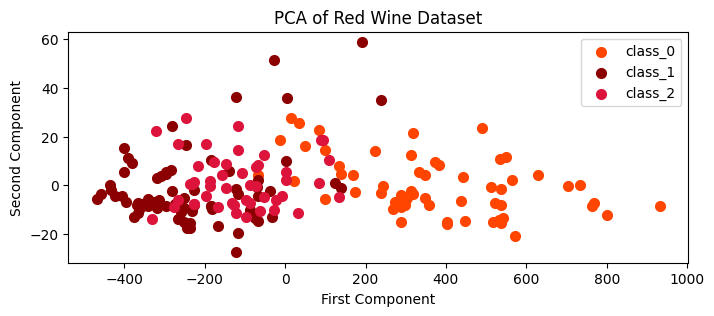

In [37]:
# Wine colors are assumption
wine_colors = ['orangered', 'darkred', 'crimson']
num_classes = [0,1,2]

plt.figure(figsize=(8,3))

for color, num_class, target_name in zip(wine_colors, num_classes, target_names):
    
    plt.scatter(X_reduced[y==num_class,0], X_reduced[y==num_class,1], 
                c=color,linewidths=2,label=target_name, cmap='jet')
    
plt.title('PCA of Red Wine Dataset')
plt.xlabel('First Component')
plt.ylabel('Second Component')
plt.legend()

__Code Breakdown__\
`y==num_class`: This is a boolean indexing operation. It creates a boolean mask that is True for every row in y that matches the current num_class (e.g., 0, 1, or 2) and False otherwise.\
`X_reduced[y==num_class, 0]`: This selects all rows from X_reduced where the condition y==num_class is True, and then selects the first column (the first principal component) for those rows. This provides all the x-coordinates for the current class.\
*For e.g. - during the first loop iteration where num_class is 0, the boolean mask will be True for every data point that has the label 0 and False for all others.*\
`X_reduced[y==num_class, 1]`: Similarly, this selects the second column (the second principal component) for the same rows. This provides all the y-coordinates for the current class.\
`c=color:` Sets the color for all points belonging to the current class, using the color variable from the loop (e.g., 'orangered').\
`linewidths=8`: Sets the width of the markers' edges to a thick value of 8.\
`label=target_name`: Provides a label for the current class, which will be used to create a legend.\
`cmap='jet'`: Specifies a colormap to use. While a specific color is provided, cmap can be used to set the color of points based on a third variable. In this case, c=color overrides the colormap, but it can still be included for other plot customizations. 

For the scatter plot, above we plotted the two principal components and also used colors to differentiate the classes.

Although we are able to visualize the entire dataset (by reducing the dimension) and we can see all 3 classes in one plot due to that it is reduced into 2 components, it's hard to interpret these components.

Let's see the components

### __Interpreting the Principal Components__

In [40]:
pca.components_ , pca.n_components_ , pca.components_.shape

(array([[ 1.65926472e-03, -6.81015556e-04,  1.94905742e-04,
         -4.67130058e-03,  1.78680075e-02,  9.89829680e-04,
          1.56728830e-03, -1.23086662e-04,  6.00607792e-04,
          2.32714319e-03,  1.71380037e-04,  7.04931645e-04,
          9.99822937e-01],
        [ 1.20340617e-03,  2.15498184e-03,  4.59369254e-03,
          2.64503930e-02,  9.99344186e-01,  8.77962152e-04,
         -5.18507284e-05, -1.35447892e-03,  5.00440040e-03,
          1.51003530e-02, -7.62673115e-04, -3.49536431e-03,
         -1.77738095e-02]]),
 2,
 (2, 13))

The first row of the above components is the First Principal Component and the second row is the Second Principal Component. The columns are the features.

In order to understand these components, we can also visualize them using heatmap.

<Axes: >

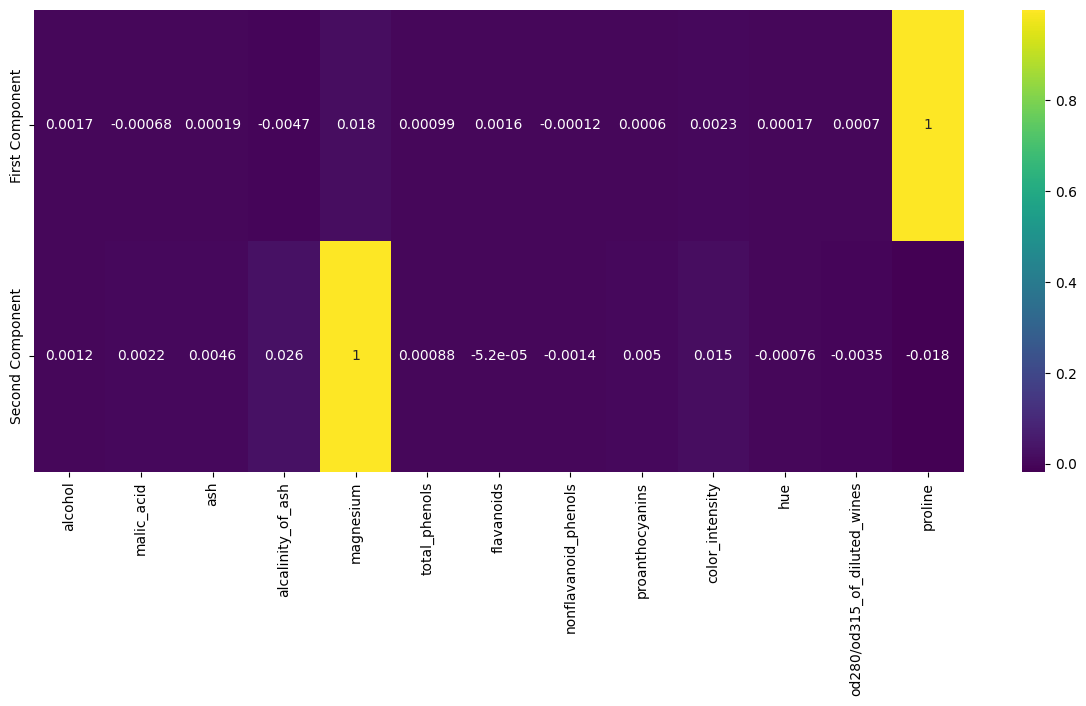

In [41]:
plt.figure(figsize=(15,6))

sns.heatmap(pca.components_, annot=True, cmap='viridis',
            xticklabels=feat_names, 
            yticklabels=['First Component', 'Second Component'])

The above heatmap can be easy to interpret. It shows how much of a given feature is represented in the particular component.

### __Explained Variance Ratio__
Explained Variance Ratio shows the percentage of the dataset variance explained by each principal components.

pca.explained_variance_ will show the whole variance amount. Whereas pca.explained_variance_ratio_ will show the percentage variance.

In [43]:
pca.explained_variance_ , pca.explained_variance_ratio_

(array([99201.78951748,   172.53526648]), array([0.99809123, 0.00173592]))

The Explained Variance Ration in our case is `[0.99809123, 0.00173592]`. It means that `99.8%` of the dataset variance lies on the first component, and the rest `0.17%` lies on the second component.

If you look back to the heatmap above, on the y axis specifically, the above can make sense.

__Important notes__: If you got the explained variance ratio of `[0.36198848, 0.1920749]`, the reason was that I used the scaled data and probably didn't rerun the cell above. Using the unscaled data in pca.fit_transform() should give the explained variance ratio of (or close to) `[0.99809123, 0.00173592]` .

### __Choosing Number of Components__
One of the hardest thing using PCA might be to choose the number of principal components that will retain as much as information as possible. Most of the time, 2 or 3 components will be it, but you want to choose them based off the variance ratio.

There is a better way to find them using cumsum.

13


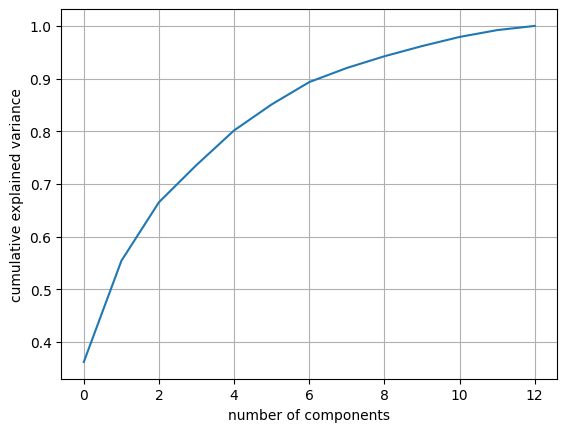

In [46]:
# Finding the right number of components by plotting no of components Vs explained variance ratio

from sklearn.decomposition import PCA

pca_2 = PCA()

pca_2.fit(X_scaled)
print(pca_2.n_components_)

# Explained variance ratio
exp_var_ratio = pca_2.explained_variance_ratio_

# Cumulative sum of the variance ratios

cumsum = np.cumsum(exp_var_ratio)

# Plotting number of components Vs explained variance ratio

plt.plot(cumsum)

plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.grid()

In [50]:
# Finding the number of components from desired explained variance ratio

from sklearn.decomposition import PCA

pca_3 = PCA(n_components=0.96)

X_reduced = pca_3.fit_transform(X_scaled)

In [52]:
pca_3.n_components_

np.int64(10)

In [53]:
np.sum(pca_3.explained_variance_ratio_)

np.float64(0.9616971684450643)

## __PCA for Visualizing Hand Written Digits__

Like we have been saying, PCA can be used to visualize the high dimensional dataset.

Let us attempt to visualize the handwritten digits

In [56]:
from sklearn.datasets import load_digits

digits = load_digits()

In [60]:
digits_data = digits.data
digits_data .shape

(1797, 64)

Each digits has 64 dimensions, that is 8*8 pixels. We can use PCA to project those 64 dimensions into 2 dimensions or components.

__Using PCA to Reduce the Dimensionality__

In [61]:
dig_pca = PCA(n_components=2)

digit_reduced = dig_pca.fit_transform(digits_data)

In [62]:
# Shape of the reduced digits

print('The shape of orginal digits(without PCA):{}\nThe shape of reduced digits due to PCA:{}'.format(digits_data.shape, digit_reduced.shape))

The shape of orginal digits(without PCA):(1797, 64)
The shape of reduced digits due to PCA:(1797, 2)


__Visualizing the Digits__

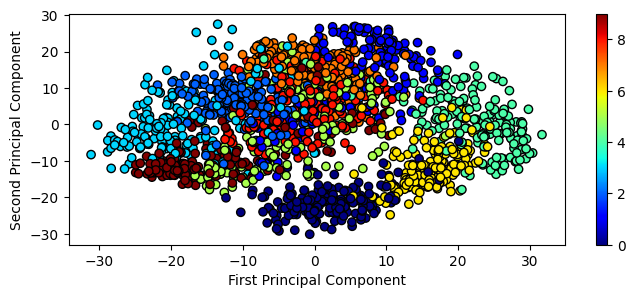

In [65]:
plt.figure(figsize=(8,3))

plt.scatter(digit_reduced[:,0],digit_reduced[:,1],
           c=digits.target,cmap='jet', edgecolor='black')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar()

That is so fantastic. Imagine that we are able to visualize all 10 digits into one plot, just because we have reduced their dimensions from 64 to 2.

# __Conclusion__

Principal Component Analysis (PCA) is a technique for simplifying complex datasets by reducing the number of variables, or dimensions, while preserving most of the important information. As an unsupervised learning method, it finds patterns in data without using predefined categories.\
_Imagine you are a fruit market manager with data on hundreds of types of fruit, including:_\
__Size__: Length, width, and height.\
__Appearance__: Color (RGB values), texture, and stem length.\
__Nutrients__: Vitamin C, sugar content, and fiber. \

You want to understand the key differences between all these fruits, but keeping track of nine different features is too complex. You need a simpler summary.\
__This is where PCA comes in, acting like a smart data summarizer:__
* Finds the main directions of variation: PCA finds the "principal components," which are new dimensions that capture the most variation in your data. In the fruit example, the first principal component (PC1) might capture the overall "size" of the fruit, explaining a large portion of the differences between fruits. A second principal component (PC2) might capture the contrast between "sweetness and tartness," explaining the next-largest portion of variation.
* Condenses information: Each fruit gets a "score" on these new dimensions. So, instead of a nine-number profile, a fruit can be described by just its PC1 and PC2 scores. An apple might have a high PC1 score (average size) and a medium PC2 score, while a watermelon would have a very high PC1 score (large size) and a very high PC2 score.
* Lets you discard less important information: Other components, like a third one representing the difference between red and green coloring, might explain very little variation and can be discarded. This is the essence of dimensionality reduction: you keep the most important information while throwing out the noise and redundancy.\
__Does PCA help in predicting values?__\
No, a PCA model itself does not predict values or outcomes. It is a data preprocessing and analysis tool, not a predictive machine learning algorithm.\ 
_PCA is unsupervised:_ A prediction model is a `"supervised"` task, which requires a target variable to predict. PCA is `"unsupervised"` because it analyzes the relationships between features without any knowledge of a target variable, like whether the fruit is sweet or tart.
PCA is a feature extractor: PCA's job is to create a new, simpler feature set. This new dataset can then be fed into a different predictive model (like logistic regression or a neural network) to make predictions. \
_Example:_\
To predict whether a new fruit is sweet or tart:
Use PCA to reduce dimensions: Apply PCA to the fruit features (color, size, etc.) to get a smaller set of principal components.\
__Train a predictive model:__ Feed the new, condensed dataset into a supervised model, such as a logistic regression classifier, along with the correct "sweet" or "tart" labels.\
__Make a prediction:__ When a new fruit arrives, you first run its data through your PCA model to get its principal component scores, and then you feed those scores into your trained logistic regression model, which will output the prediction of whether it's sweet or tart.

